In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)

In [ ]:

train=pd.read_csv('/content/drive/MyDrive/titanictrain.csv')
test=pd.read_csv('/content/drive/MyDrive/titanictest.csv')

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
train.shape

(891, 12)

In [ ]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
train['Sex'].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Sex'>

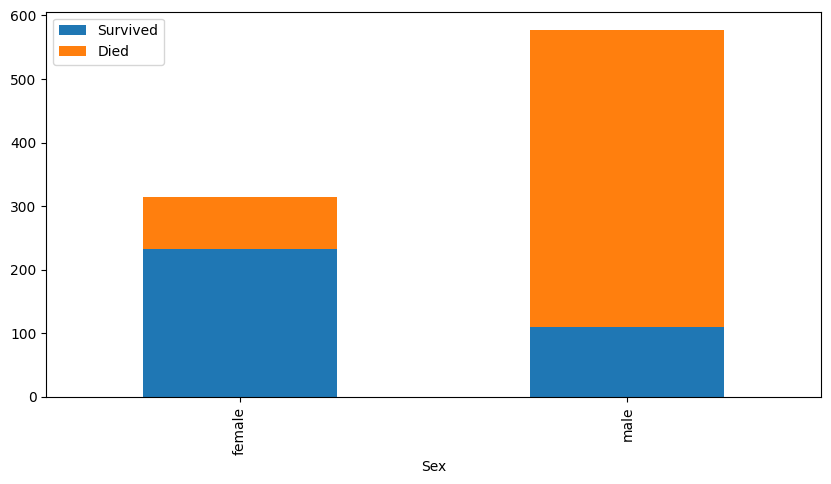

In [ ]:
train['Died']=1-train['Survived']
train.groupby('Sex')[['Survived','Died']].agg('sum').plot(kind='bar',figsize=(10,5),stacked=True)

In [ ]:
train['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Died         891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [ ]:
train.isnull().mean()*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [ ]:
train[train.duplicated()].shape[0]

0

In [ ]:
train.rename(columns={'Pclass':'Ticket Class','SibSp':'siblings/spouses','Ticket':'Ticket No'}
             ,inplace=True)

In [ ]:
train.head()

,PassengerId,Survived,Ticket Class,Name,Sex,Age,siblings/spouses,Parch,Ticket No,Fare,Cabin,Embarked,Died
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [ ]:
train['PassengerId'].nunique()

891

In [ ]:
del train['PassengerId']

In [ ]:
del train['Died']

In [ ]:
train.head()

,Survived,Ticket Class,Name,Sex,Age,siblings/spouses,Parch,Ticket No,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
for cols in ['Survived','Ticket Class','Embarked','siblings/spouses','Sex','Parch']:
  print(cols,train[cols].unique())

Survived [0 1]
Ticket Class [3 1 2]
Embarked ['S' 'C' 'Q' nan]
siblings/spouses [1 0 3 4 2 5 8]
Sex ['male' 'female']
Parch [0 1 2 5 3 4 6]


In [ ]:
train['Ticket Code']=pd.factorize(train['Ticket No'])[0]

In [ ]:
corr=train[['Ticket Code','Survived']].corr()
print(corr)

             Ticket Code  Survived
Ticket Code     1.000000 -0.047298
Survived       -0.047298  1.000000


In [ ]:
del train['Ticket No']

In [ ]:
del train['Ticket Code']

In [ ]:
train.head()

,Survived,Ticket Class,Name,Sex,Age,siblings/spouses,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S


In [ ]:
train['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [ ]:
train['Has_Cabin'] = train['Cabin'].notnull().astype(int)
#Extract the deck (first letter of Cabin)
train['Deck'] = train['Cabin'].astype(str).str[0]
#Replace 'n' (from 'nan') with 'U' (Unknown deck)
train['Deck'] = train['Deck'].replace('n', 'U')
#One-hot encode the Deck column
train = pd.get_dummies(train, columns=['Deck'], drop_first=True)
print(train[['Cabin', 'Has_Cabin'] + [col for col in train.columns if col.startswith('Deck_')]].head())


  Cabin  Has_Cabin  Deck_B  Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  \
0   NaN          0   False   False   False   False   False   False   False   
1   C85          1   False    True   False   False   False   False   False   
2   NaN          0   False   False   False   False   False   False   False   
3  C123          1   False    True   False   False   False   False   False   
4   NaN          0   False   False   False   False   False   False   False   

   Deck_U  
0    True  
1   False  
2    True  
3   False  
4    True  


In [ ]:
del train['Cabin']

In [ ]:
train.head(4)

,Survived,Ticket Class,Name,Sex,Age,siblings/spouses,Parch,Fare,Embarked,Has_Cabin,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,0,False,False,False,False,False,False,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,1,False,True,False,False,False,False,False,False
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,0,False,False,False,False,False,False,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,1,False,True,False,False,False,False,False,False


In [ ]:
train['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
train['Embarked']=train['Embarked'].fillna(train['Embarked'].mode()[0])

In [ ]:
train['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
train['Title Name']=train['Name'].str.extract('([A-Za-z]+)\.',expand=False)


In [ ]:
train['Title Name'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [ ]:
del train['Name']

In [ ]:
rare_titles=[ 'Don', 'Rev', 'Dr', 'Mme', 'Ms','Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess','Jonkheer']
train['Title Name']=train['Title Name'].replace(rare_titles,'Rare')

In [ ]:
train['Title Name'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

In [ ]:
train.head()

,Survived,Ticket Class,Sex,Age,siblings/spouses,Parch,Fare,Embarked,Has_Cabin,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Title Name
0,0,3,male,22.0,1,0,7.2500,S,0,False,False,False,False,False,False,False,True,Mr
1,1,1,female,38.0,1,0,71.2833,C,1,False,True,False,False,False,False,False,False,Mrs
2,1,3,female,26.0,0,0,7.9250,S,0,False,False,False,False,False,False,False,True,Miss
3,1,1,female,35.0,1,0,53.1000,S,1,False,True,False,False,False,False,False,False,Mrs
4,0,3,male,35.0,0,0,8.0500,S,0,False,False,False,False,False,False,False,True,Mr


In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols=['Sex','Embarked','Title Name']
encoder=OneHotEncoder(sparse_output=False,drop='first')
encoded_array=encoder.fit_transform(train[categorical_cols])
encoded_cols=encoder.get_feature_names_out(categorical_cols)
encoded_df=pd.DataFrame(encoded_array,columns=encoded_cols,index=train.index)

train_encoded=pd.concat([train.drop(columns=categorical_cols),encoded_df],axis=1)

print(train_encoded.head())





   Survived  Ticket Class   Age  siblings/spouses  Parch     Fare  Has_Cabin  \
0         0             3  22.0                 1      0   7.2500          0   
1         1             1  38.0                 1      0  71.2833          1   
2         1             3  26.0                 0      0   7.9250          0   
3         1             1  35.0                 1      0  53.1000          1   
4         0             3  35.0                 0      0   8.0500          0   

   Deck_B  Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  Deck_U  Sex_male  \
0   False   False   False   False   False   False   False    True       1.0   
1   False    True   False   False   False   False   False   False       0.0   
2   False   False   False   False   False   False   False    True       0.0   
3   False    True   False   False   False   False   False   False       0.0   
4   False   False   False   False   False   False   False    True       1.0   

   Embarked_Q  Embarked_S  Title Name_Miss  

In [ ]:
train_encoded.head()

,Survived,Ticket Class,Age,siblings/spouses,Parch,Fare,Has_Cabin,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Sex_male,Embarked_Q,Embarked_S,Title Name_Miss,Title Name_Mr,Title Name_Mrs,Title Name_Rare
0,0,3,22.0,1,0,7.2500,0,False,False,False,False,False,False,False,True,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1,1,38.0,1,0,71.2833,1,False,True,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,3,26.0,0,0,7.9250,0,False,False,False,False,False,False,False,True,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,1,1,35.0,1,0,53.1000,1,False,True,False,False,False,False,False,False,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0,3,35.0,0,0,8.0500,0,False,False,False,False,False,False,False,True,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
deck_cols=[col for col in train_encoded.columns  if col.startswith('Deck_')]
train_encoded[deck_cols]=train_encoded[deck_cols].astype(int)

In [ ]:
train_encoded.head()

,Survived,Ticket Class,Age,siblings/spouses,Parch,Fare,Has_Cabin,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Sex_male,Embarked_Q,Embarked_S,Title Name_Miss,Title Name_Mr,Title Name_Mrs,Title Name_Rare
0,0,3,22.0,1,0,7.2500,0,0,0,0,0,0,0,0,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1,1,38.0,1,0,71.2833,1,0,1,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,3,26.0,0,0,7.9250,0,0,0,0,0,0,0,0,1,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,1,1,35.0,1,0,53.1000,1,0,1,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0,3,35.0,0,0,8.0500,0,0,0,0,0,0,0,0,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0


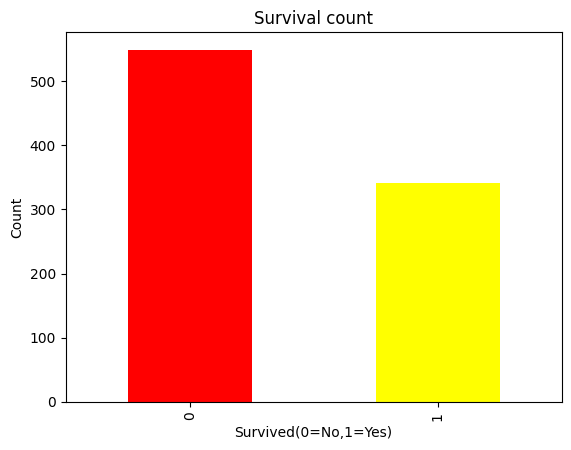

In [ ]:
train_encoded['Survived'].value_counts().plot(kind='bar',color=['red','yellow'])
plt.title('Survival count')
plt.xlabel('Survived(0=No,1=Yes)')
plt.ylabel('Count')
plt.show()

In [ ]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [ ]:
test.isnull().mean()*100

,0
PassengerId,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234
Cabin,78.229665


In [ ]:
test[test.duplicated()].shape[0]

0

In [ ]:
test.shape

(418, 11)

In [ ]:
test['PassengerId'].nunique()

418

In [ ]:
del test['PassengerId']

In [ ]:
test.rename(columns={'Pclass':'Ticket Class','SibSp':'siblings/spouses','Ticket':'Ticket No'}
             ,inplace=True)

In [ ]:
del test['Cabin']

In [ ]:
del test['Ticket No']

In [ ]:
test['Embarked'].unique()

array(['Q', 'S', 'C'], dtype=object)

In [ ]:
test.head()

,Ticket Class,Name,Sex,Age,siblings/spouses,Parch,Fare,Embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,S


In [ ]:
for cols in ['Ticket Class','Embarked','siblings/spouses','Sex','Parch']:
  print(cols,test[cols].unique())

Ticket Class [3 2 1]
Embarked ['Q' 'S' 'C']
siblings/spouses [0 1 2 3 4 5 8]
Sex ['male' 'female']
Parch [0 1 3 2 4 6 5 9]


In [ ]:
test['Title Name']=test['Name'].str.extract('([A-Za-z]+)\.',expand=False)


In [ ]:
del test['Name']

In [ ]:
test.head()

,Ticket Class,Sex,Age,siblings/spouses,Parch,Fare,Embarked,Title Name
0,3,male,34.5,0,0,7.8292,Q,Mr
1,3,female,47.0,1,0,7.0000,S,Mrs
2,2,male,62.0,0,0,9.6875,Q,Mr
3,3,male,27.0,0,0,8.6625,S,Mr
4,3,female,22.0,1,1,12.2875,S,Mrs


In [ ]:
train_titles = ['Miss','Mr','Mrs','Rare']
test_titles = test['Title Name'].unique()

In [ ]:
train['Title Name'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

In [ ]:
test['Title Name'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Ms', 'Col', 'Rev', 'Dr', 'Dona'],
      dtype=object)

In [ ]:
rare_titles=['Ms', 'Col', 'Rev', 'Dr', 'Dona']
test['Title Name']=test['Title Name'].replace(rare_titles,'Rare')

In [ ]:
test['Title Name'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

In [ ]:
train['Sex'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
test['Sex'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
train['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
test['Embarked'].unique()

array(['Q', 'S', 'C'], dtype=object)

In [ ]:
test_categorical=encoder.transform(test[['Sex','Embarked','Title Name']])
test_numeric=test[['Ticket Class','Age','siblings/spouses','Parch','Fare']]
test_final=np.concatenate([test_numeric,test_categorical],axis=1)

In [ ]:
x_train=train_encoded.drop('Survived',axis=1)
y_train=train_encoded['Survived']

In [ ]:
cat_columns = encoder.get_feature_names_out(['Sex','Embarked','Title Name'])
num_columns = ['Ticket Class','Age','siblings/spouses','Parch','Fare']
all_columns = num_columns + list(cat_columns)


test_df = pd.DataFrame(test_final, columns=all_columns)


In [ ]:
train_columns = x_train.columns

for col in train_columns:
    if col not in test_df.columns:
        test_df[col] = 0

x_test_final = test_df[train_columns]


In [ ]:
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.ensemble import RandomForestClassifier


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)





In [ ]:
final_model=RandomForestClassifier(n_estimators=500,criterion='entropy',
                                   max_depth=10,max_features=None,min_samples_leaf=2,
                                   min_samples_split=5,random_state=42)

In [ ]:
final_model.fit(X_tr, y_tr)

RandomForestClassifier(criterion='entropy', max_depth=10, max_features=None,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=500, random_state=42)

In [ ]:
y_pred=final_model.predict(X_val)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report,roc_curve,auc


In [ ]:
print(final_model.score(X_val,y_val))

0.8324022346368715


In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
scores = cross_val_score(final_model,X_tr, y_tr, cv=5, scoring='accuracy')
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.825844577957254


              precision    recall  f1-score   support

           0       0.82      0.91      0.86       105
           1       0.85      0.72      0.78        74

    accuracy                           0.83       179
   macro avg       0.84      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



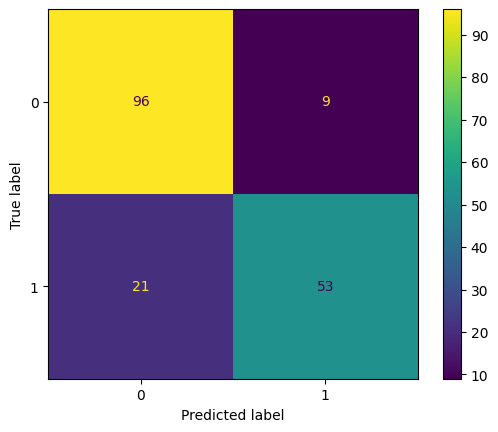

In [ ]:
# Confusion matrix
cm = ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
print(cm)
print(classification_report(y_val, y_pred))

In [ ]:
y_test_pred=final_model.predict(x_test_final)
print(y_test_pred)

[0 1 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 1 0 0 0
 1 0 0 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 1 0
 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 1 1 0 0 1 0 0 1]


In [ ]:
pd.DataFrame({'Predicted Survived': y_test_pred}).head(10)


,Predicted Survived
0,0
1,1
2,0
3,0
4,1
5,0
6,1
7,0
8,1
9,0


In [ ]:
test.head(10)

,Ticket Class,Sex,Age,siblings/spouses,Parch,Fare,Embarked,Title Name
0,3,male,34.5,0,0,7.8292,Q,Mr
1,3,female,47.0,1,0,7.0000,S,Mrs
2,2,male,62.0,0,0,9.6875,Q,Mr
3,3,male,27.0,0,0,8.6625,S,Mr
4,3,female,22.0,1,1,12.2875,S,Mrs
5,3,male,14.0,0,0,9.2250,S,Mr
6,3,female,30.0,0,0,7.6292,Q,Miss
7,2,male,26.0,1,1,29.0000,S,Mr
8,3,female,18.0,0,0,7.2292,C,Mrs
9,3,male,21.0,2,0,24.1500,S,Mr


In [ ]:
matches=y_val==y_pred
print(matches[:10])

709    False
439     True
840     True
720     True
39     False
290     True
300     True
333     True
208     True
136     True
Name: Survived, dtype: bool
